In [1]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np
from flow_matching.visualization import save_projections_as_gif
from flow_matching.datasets.synthetic_datasets import DatasetkappaGMM
from flow_matching.solver import TimeBroadcastWrapper, sample_ode

# Investigate inference data

- load the data

In [48]:
dim=2048
kappa = 0.3
output_dir = Path(f'../outputs/cfm/kappagmm_{dim}_{kappa}')
mus = torch.load(output_dir / 'mus.pt')
m1 = (mus[0] + mus[1]) / 2
m2 = (mus[0] - mus[1]) / 2
data = torch.load(output_dir / 'basis_proj.pt')
projections = data['projections']
times = data['eval_times']

p1 = projections[:,:,0].cpu().numpy()
p2 = projections[:,:,1].cpu().numpy()

/tmp/ipykernel_28144/465485348.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mus = torch.load(output_dir / 'mus.pt')
/tmp/ipykernel_28144/465485348.py:7: FutureWarning

In [49]:
p1.shape

(1, 20000)

In [44]:
p1.shape

(1, 1000)

- ref samples

In [50]:
nsamples = int(1e4)
dataset = DatasetkappaGMM(dim=dim,device=mus.device, kappa=kappa)
dataset.mus = mus
ref_samples = dataset.sample(nsamples)
r1 = (ref_samples @ m1 / dim).cpu().numpy()
r2 = (ref_samples @ m2 / dim).cpu().numpy()

- plot

In [51]:
# Pre-compute reference KDE once
kde_ref = gaussian_kde(np.vstack([r1, r2]), bw_method=0.5)
# Pre-evaluate on a fixed grid once
x_grid = np.linspace(2 * r1.min(), 2 * r1.max(), 100)
y_grid = np.linspace(2 * r2.min(), 2 * r2.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = kde_ref(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

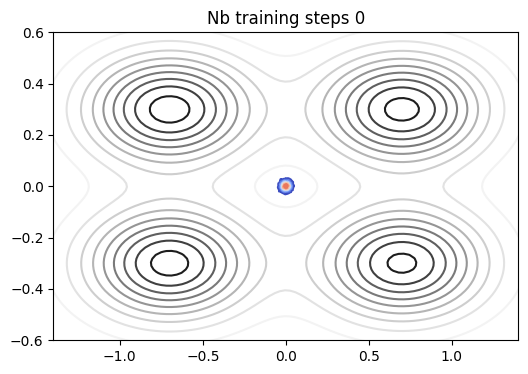

In [52]:
for i in range(0,1):

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sns.kdeplot(
                x=p1[i], 
                y=p2[i],
                ax=ax,
                cmap='coolwarm',
                fill=False,      # no fill, just contour lines
                levels=10,       # number of iso-density levels
                bw_adjust=0.5,
            )
    
    # use precomputed for reference
    ax.contour(X, Y, Z, levels=10, cmap='Greys')
    ax.set_xlim(-2 * (1-kappa), 2 * (1-kappa))
    ax.set_ylim(-2 * kappa, 2 * kappa)
    ax.set_title(f"Nb training steps {times[i]}")
    plt.show()

- initially

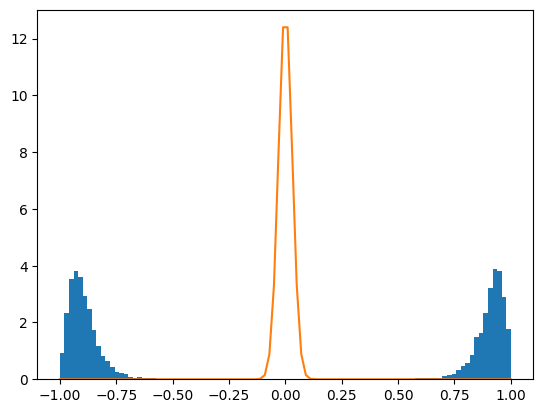

In [34]:
xs = np.linspace(-1.0,1.0, 100)
std =  (1-kappa) ** 0.5 / ( dim) ** 0.5
# std = 0.1 * (kappa) ** 0.5 / ( dim) ** 0.5
plt.hist(p1[20], bins=xs, density=True)
# plt.hist(r1, bins=xs, density=True)
plt.plot(xs, np.exp(- (xs)  ** 2 / (2 * std ** 2)) / (2 * np.pi * std ** 2) ** 0.5)
plt.show()

- finally

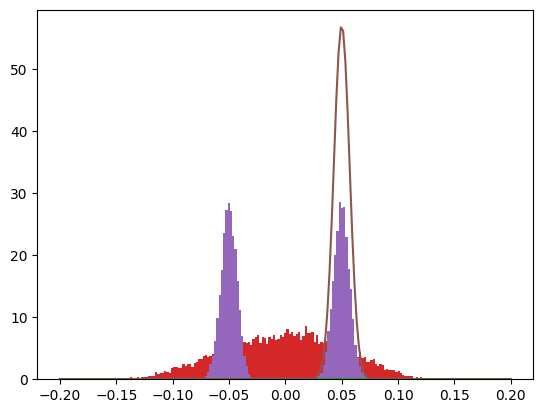

In [43]:
xs = np.linspace(-0.2,0.2, 200)
std =  (1-kappa) ** 0.5 / ( dim) ** 0.5
# std = 0.1 * (kappa) ** 0.5 / ( dim) ** 0.5
plt.hist(p1[-1], bins=xs, density=True)
plt.hist(r1, bins=xs, density=True)
plt.plot(xs, np.exp(- (xs-(1-kappa))  ** 2 / (2 * std ** 2)) / (2 * np.pi * std ** 2) ** 0.5)
# plt.show()

std =  (kappa) ** 0.5 / ( dim) ** 0.5
plt.hist(p2[20], bins=xs, density=True)
plt.hist(r2, bins=xs, density=True)
plt.plot(xs, np.exp(- (xs-(kappa))  ** 2 / (2 * std ** 2)) / (2 * np.pi * std ** 2) ** 0.5)
plt.show()

It seems like we pushed the training too far here.

# Mode identification analysis

In [31]:
dim=1024
kappas = [0.0125,0.025, 0.05, 0.1, 0.2]
data_dic = {}
for kappa in kappas:
    output_dir = Path(f'../outputs/cfm/kappagmm_{dim}_{kappa}')
    mus = torch.load(output_dir / 'mus.pt')
    m1 = (mus[0] + mus[1]) / 2
    m2 = (mus[0] - mus[1]) / 2
    data = torch.load(output_dir / 'basis_proj.pt')
    projections = data['projections']
    times = data['eval_times']
    data_dic[f'kappagmm_{dim}_{kappa}'] = {
        'projections' : projections,
        'times' : times
    }

/tmp/ipykernel_28144/1413680069.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mus = torch.load(output_dir / 'mus.pt')
/tmp/ipykernel_28144/1413680069.py:9: FutureWarni

- plot mode learning

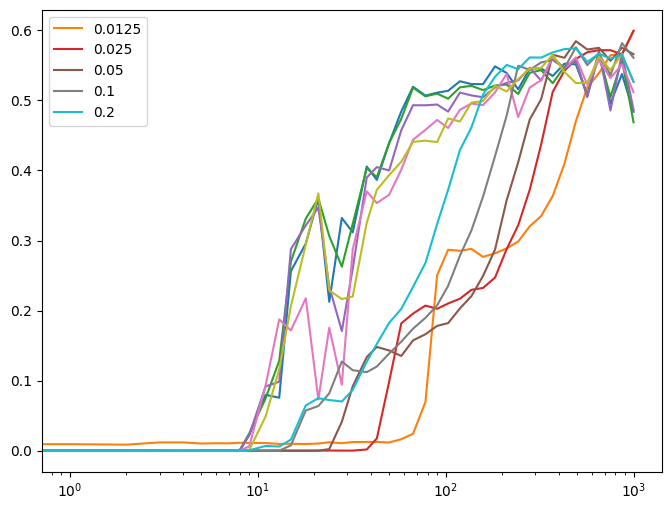

In [32]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

for k,v in data_dic.items():
    kappa = float(k.split('_')[-1])
    # print(kappa)
    projections = v['projections']
    p1 = projections[:,:,0]
    p2 = projections[:,:,1]
    times = v['times']

    width=1
    std1 = (1 - kappa) ** 0.5 / dim ** 0.5
    m1_prop = torch.logical_or((p1 - (1-kappa)).abs() < width * std1,(p1 + (1-kappa)).abs() < width * std1).float().mean(1)

    std2 = kappa ** 0.5 / dim ** 0.5
    m2_prop = torch.logical_or((p2 - (kappa)).abs() < width * std2,(p2 + (kappa)).abs() < width * std2).float().mean(1)


    ax.plot(
        times,
        m1_prop
    )
    
    ax.plot(
        times,
        m2_prop,
        label=f'{kappa}'
    )

ax.set_xscale('log')
ax.legend()

    # break

- rescale by kappa

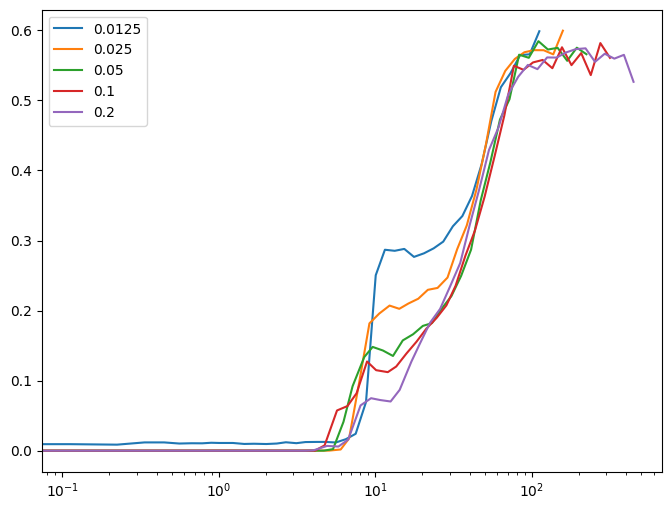

In [34]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

for k,v in data_dic.items():
    kappa = float(k.split('_')[-1])
    # print(kappa)
    projections = v['projections']
    p1 = projections[:,:,0]
    p2 = projections[:,:,1]
    times = v['times']

    width=1
    std1 = (1 - kappa) ** 0.5 / dim ** 0.5
    m1_prop = torch.logical_or((p1 - (1-kappa)).abs() < width * std1,(p1 + (1-kappa)).abs() < width * std1).float().mean(1)

    std2 = kappa ** 0.5 / dim ** 0.5
    m2_prop = torch.logical_or((p2 - (kappa)).abs() < width * std2,(p2 + (kappa)).abs() < width * std2).float().mean(1)


    # ax.plot(
    #     times,
    #     m1_prop
    # )
    
    ax.plot(
        times * kappa ** 0.5,
        m2_prop,
        label=f'{kappa}'
    )

ax.set_xscale('log')
ax.legend()

    # break

- seems more like a dynamics in $\sqrt{\kappa}$ ! 

In [173]:
data_dic['kappagmm_1024_0.0125']['times'].shape

torch.Size([40])

In [20]:
data.keys()

dict_keys(['projections', 'eval_times'])

# sanbox

In [ ]:
import torch.nn as nn
from jaxtyping import Float
from torch import Tensor

class Mlp(nn.Module):
    def __init__(self, dim: int = 2, time_dim: int = 1, h: int = 64) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(dim + time_dim, h),
            nn.SiLU(),
            nn.Linear(h, h),
            nn.SiLU(),
            nn.Linear(h, h),
            nn.SiLU(),
            nn.Linear(h, dim),
        )

    def forward(
        self,
        x_t: Float[Tensor, "batch dim"],
        t: Float[Tensor, "batch time_dim"],
    ) -> Float[Tensor, "batch dim"]:
        h = torch.cat([x_t, t], dim=1)
        return self.layers(h)

from flow_matching.solver import sample_ode, ModelWrapper

In [ ]:
flow = Mlp(
    dim = dim,
    time_dim=1,
    h=512
)

flow.load_state_dict(torch.load('/home/klinger/flow-matching/outputs/cfm/kappagmm_1024_0.3/ckpt.pth'))
flow = flow.to(mus.device)

/tmp/ipykernel_26546/2070932274.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load('/home/klinger/flow-matching/outputs/cfm/kappagmm_1024_0.

In [ ]:

wrapped_model = TimeBroadcastWrapper(flow)
sampled_data_ = sample_ode(
flow=wrapped_model,
dim=dim,
num_samples=int(1e4), # hard code, sufficient for our needs,
step_size=0.05
# filename=f"ode_sampling_evolution_{args.dataset}.png",
)

In [ ]:
p1 = (sampled_data_ @ m1 / dim).cpu().numpy()
p2 = (sampled_data_ @ m2 / dim).cpu().numpy()

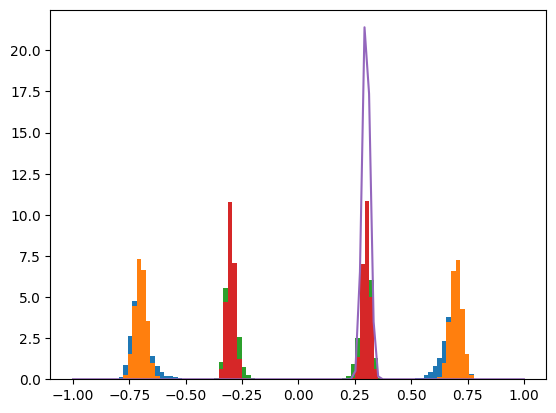

In [ ]:
xs = np.linspace(-1.0,1.0, 100)
std = (1-kappa) ** 0.5 / ( dim) ** 0.5
std = (kappa) ** 0.5 / ( dim) ** 0.5
plt.hist(p1, bins=xs, density=True)
plt.hist(r1, bins=xs, density=True)
plt.hist(p2, bins=xs, density=True)
plt.hist(r2, bins=xs, density=True)
plt.plot(xs, np.exp(- (xs - (kappa))  ** 2 / (2 * std ** 2)) / (2 * np.pi * std ** 2) ** 0.5)
plt.show()

In [36]:
torch.stack([torch.randn(10,2) for _ in range(5)]).shape

torch.Size([5, 10, 2])